In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import os

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


In [2]:
# dataset_url = "https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip"
# data_dir = tf.keras.utils.get_file('cats_and_dogs_filtered.zip', origin=dataset_url, extract=True)
# base_dir = os.path.join(os.path.dirname(data_dir), 'cats_and_dogs_filtered')

# train_dir = os.path.join(base_dir, 'train')
# validation_dir = os.path.join(base_dir, 'validation')

# print("Training directory:", train_dir)
# print("Validation directory:", validation_dir)

68606236/68606236 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training directory: /root/.keras/datasets/cats_and_dogs_filtered/train
Validation directory: /root/.keras/datasets/cats_and_dogs_filtered/validation


In [3]:
# import os

# train_dir = '/root/.keras/datasets/cats_and_dogs_filtered/train'
# val_dir = '/root/.keras/datasets/cats_and_dogs_filtered/validation'

# print("Train cats:", len(os.listdir(os.path.join(train_dir, 'cats'))))
# print("Train dogs:", len(os.listdir(os.path.join(train_dir, 'dogs'))))
# print("Validation cats:", len(os.listdir(os.path.join(val_dir, 'cats'))))
# print("Validation dogs:", len(os.listdir(os.path.join(val_dir, 'dogs'))))

FileNotFoundError: [Errno 2] No such file or directory: '/root/.keras/datasets/cats_and_dogs_filtered/train/cats'

In [3]:
import shutil
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import os
import zipfile

dataset_url = "https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip"
data_dir = tf.keras.utils.get_file('cats_and_dogs_filtered.zip', origin=dataset_url, extract=False) # Don't extract automatically
base_dir = os.path.join(os.path.dirname(data_dir), 'cats_and_dogs_filtered')

# Explicitly unzip the dataset
with zipfile.ZipFile(data_dir, 'r') as zip_ref:
    zip_ref.extractall(os.path.dirname(data_dir))

# Create a directory in Google Drive to store dataset
drive_dataset_path = "/content/drive/MyDrive/cats_and_dogs_filtered"

# Copy dataset to Drive (only if not already copied)
if not os.path.exists(drive_dataset_path):
    shutil.copytree(base_dir, drive_dataset_path)
    print(f"✅ Dataset copied to: {drive_dataset_path}")
else:
    print(f"✅ Dataset already exists at: {drive_dataset_path}")

✅ Dataset copied to: /content/drive/MyDrive/cats_and_dogs_filtered


In [4]:
train_dir = os.path.join(drive_dataset_path, 'train')
validation_dir = os.path.join(drive_dataset_path, 'validation')

print("Training directory:", train_dir)
print("Validation directory:", validation_dir)

Training directory: /content/drive/MyDrive/cats_and_dogs_filtered/train
Validation directory: /content/drive/MyDrive/cats_and_dogs_filtered/validation


In [5]:

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

validation_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [6]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
checkpoint_path = "/content/drive/MyDrive/best_cats_dogs_model.h5"
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = tf.keras.callbacks.ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True)

In [8]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator,
    callbacks=[early_stop, checkpoint]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5057 - loss: 0.8234

63/63 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.5056 - loss: 0.8219 - val_accuracy: 0.4980 - val_loss: 0.6922
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5053 - loss: 0.6919

63/63 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.5054 - loss: 0.6919 - val_accuracy: 0.5000 - val_loss: 0.6918
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4972 - loss: 0.6902

63/63 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.4973 - loss: 0.6902 - val_accuracy: 0.5640 - val_loss: 0.6857
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.5687 - loss: 0.6835 - val_accuracy: 0.5640 - val_loss: 0.6829
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5751 - loss: 0.6798

63/63 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - accuracy: 0.5750 - loss: 0.6798 - val_accuracy: 0.6090 - val_loss: 0.6412
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6067 - loss: 0.6566

63/63 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.6069 - loss: 0.6566 - val_accuracy: 0.6680 - val_loss: 0.6224
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.6370 - loss: 0.6470 - val_accuracy: 0.6460 - val_loss: 0.6237
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6465 - loss: 0.6363

63/63 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.6466 - loss: 0.6362 - val_accuracy: 0.6970 - val_loss: 0.6054
Epoch 9/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6723 - loss: 0.6079

63/63 ━━━━━━━━━━━━━━━━━━━━ 162s 3s/step - accuracy: 0.6722 - loss: 0.6081 - val_accuracy: 0.7000 - val_loss: 0.6109
Epoch 10/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.6823 - loss: 0.6110 - val_accuracy: 0.6940 - val_loss: 0.5785


In [9]:
val_loss, val_acc = model.evaluate(validation_generator)
print(f"\n✅ Validation Accuracy: {val_acc:.4f}")
print(f"✅ Validation Loss: {val_loss:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 545ms/step - accuracy: 0.6848 - loss: 0.5912

✅ Validation Accuracy: 0.6940
✅ Validation Loss: 0.5785


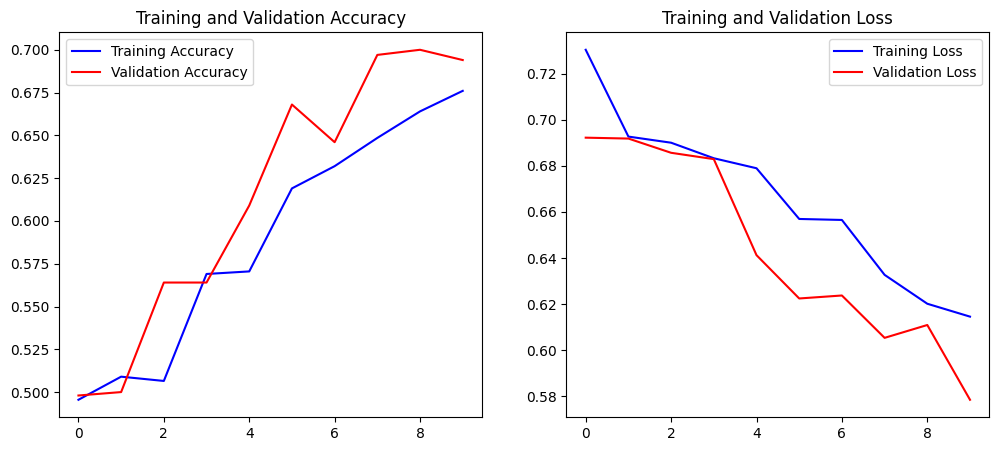

In [10]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(acc))

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

✅ TensorFlow version: 2.19.0
📁 Training data: /content/drive/MyDrive/cats_and_dogs_filtered/train
📁 Validation data: /content/drive/MyDrive/cats_and_dogs_filtered/validation
Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,581,313 (6.03 MB)

 Trainable params: 1,581,313 (6.03 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5071 - loss: 1.4746

63/63 ━━━━━━━━━━━━━━━━━━━━ 311s 5s/step - accuracy: 0.5072 - loss: 1.4684 - val_accuracy: 0.5660 - val_loss: 0.6842
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 176ms/step - accuracy: 0.5355 - loss: 0.7018 - val_accuracy: 0.5080 - val_loss: 0.6909
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 177ms/step - accuracy: 0.5243 - loss: 0.6932 - val_accuracy: 0.5650 - val_loss: 0.6846
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 179ms/step - accuracy: 0.5342 - loss: 0.6858 - val_accuracy: 0.5080 - val_loss: 0.7007
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - accuracy: 0.5802 - loss: 0.6815

✅ Validation Accuracy: 0.5660
✅ Validation Loss: 0.6842


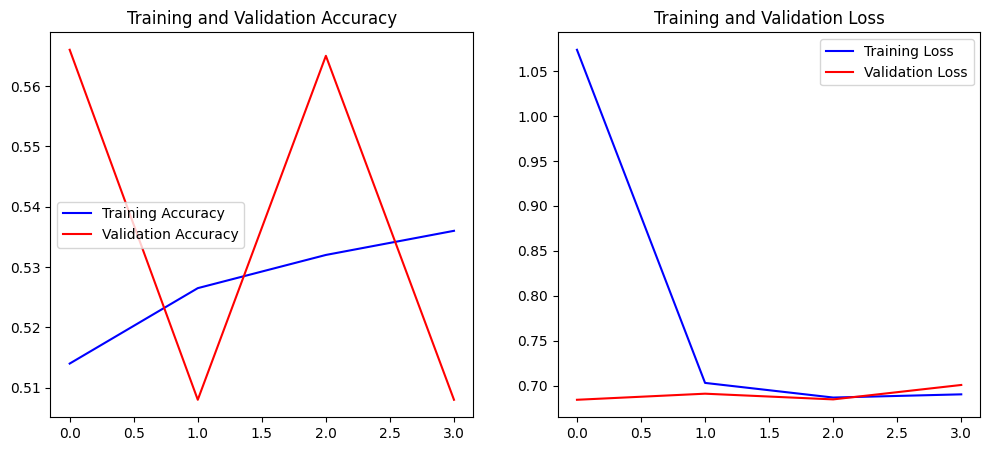

In [1]:
# =====================================================
#  Artificial Neural Network (ANN) for Cats vs Dogs
# =====================================================

# Step 1️⃣: Import Libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import os

print("✅ TensorFlow version:", tf.__version__)

# Step 2️⃣: Define Dataset Paths (already in Drive)
base_dir = "/content/drive/MyDrive/cats_and_dogs_filtered"
train_dir = os.path.join(base_dir, 'train')
val_dir   = os.path.join(base_dir, 'validation')

print("📁 Training data:", train_dir)
print("📁 Validation data:", val_dir)

# Step 3️⃣: Data Preprocessing (rescale and batch loading)
train_gen = ImageDataGenerator(rescale=1./255)
val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(64,64),
    batch_size=32,
    class_mode='binary'
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=(64,64),
    batch_size=32,
    class_mode='binary'
)

# Step 4️⃣: Build the ANN Model
model = Sequential([
    Flatten(input_shape=(64,64,3)),     # Flatten the image pixels
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')      # Output layer for binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Step 5️⃣: Setup Callbacks
checkpoint_path = "/content/drive/MyDrive/best_cats_dogs_ann.h5"
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True)

# Step 6️⃣: Train the ANN
history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

# Step 7️⃣: Evaluate Model
val_loss, val_acc = model.evaluate(val_data)
print(f"\n✅ Validation Accuracy: {val_acc:.4f}")
print(f"✅ Validation Loss: {val_loss:.4f}")

# Step 8️⃣: Plot Accuracy and Loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(acc))

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()
